In [18]:
# data manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# random forrest
from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import mean_absolute_error, mean_squared_error // removed for testing

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# google drive access



In [46]:
# load first N lines from the dataset

# N = 200000
data = pd.read_csv('data/tuesday.csv') #nrows=N

# check head
data.head(10)


,id,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,1,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,2017-07-04 11:53:44.398274,90030854,10,...,57,2.998751e+07,3.559250e+04,30013373,29946916,-1,-1,90030854,BENIGN,-1
1,2,8.6.0.1-8.0.6.4-0-0-0,8.6.0.1,0,8.0.6.4,0,0,2017-07-04 11:54:12.355218,106007973,26,...,19,1.981684e+07,8.154881e+06,27220170,7234941,-1,-1,0,BENIGN,-1
2,3,192.168.10.5-192.168.10.3-123-123-17,192.168.10.5,123,192.168.10.3,123,17,2017-07-04 11:54:32.240412,64015367,4,...,139,6.401513e+07,0.000000e+00,64015127,64015127,-1,-1,0,BENIGN,-1
3,4,192.168.10.3-192.168.10.1-60280-53-17,192.168.10.3,60280,192.168.10.1,53,17,2017-07-04 11:55:07.615878,46870,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1
4,5,192.168.10.3-192.168.10.1-61995-53-17,192.168.10.3,61995,192.168.10.1,53,17,2017-07-04 11:54:12.427035,62958,1,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1
5,6,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,2017-07-04 11:55:44.431096,61385684,57,...,73,2.997533e+07,4.153050e+04,30004697,29945964,-1,-1,181418506,BENIGN,-1
6,7,192.168.10.5-192.168.10.3-49159-445-6,192.168.10.5,49159,192.168.10.3,445,6,2017-07-04 11:58:02.036691,66,4,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,257638483,BENIGN,-1
7,8,192.168.10.50-224.0.0.251-5353-5353-17,192.168.10.50,5353,224.0.0.251,5353,17,2017-07-04 11:54:17.120201,12,9,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1
8,9,192.168.10.5-192.168.10.3-49182-88-6,192.168.10.5,49182,192.168.10.3,88,6,2017-07-04 11:54:10.131297,704,8,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,704,BENIGN,-1
9,10,192.168.10.5-192.168.10.3-49183-88-6,192.168.10.5,49183,192.168.10.3,88,6,2017-07-04 11:54:10.139647,981,10,...,0,0.000000e+00,0.000000e+00,0,0,-1,-1,981,BENIGN,-1


In [47]:
# check datatypes for columns

num_cols = len(data.columns)
print(f'Number of columns: {num_cols}')

for c in data.columns:
  print(f"{c} => {data[c].dtype}")

Number of columns: 91
id => int64
Flow ID => str
Src IP => str
Src Port => int64
Dst IP => str
Dst Port => int64
Protocol => int64
Timestamp => str
Flow Duration => int64
Total Fwd Packet => int64
Total Bwd packets => int64
Total Length of Fwd Packet => int64
Total Length of Bwd Packet => int64
Fwd Packet Length Max => int64
Fwd Packet Length Min => int64
Fwd Packet Length Mean => float64
Fwd Packet Length Std => float64
Bwd Packet Length Max => int64
Bwd Packet Length Min => int64
Bwd Packet Length Mean => float64
Bwd Packet Length Std => float64
Flow Bytes/s => float64
Flow Packets/s => float64
Flow IAT Mean => float64
Flow IAT Std => float64
Flow IAT Max => int64
Flow IAT Min => int64
Fwd IAT Total => int64
Fwd IAT Mean => float64
Fwd IAT Std => float64
Fwd IAT Max => int64
Fwd IAT Min => int64
Bwd IAT Total => int64
Bwd IAT Mean => float64
Bwd IAT Std => float64
Bwd IAT Max => int64
Bwd IAT Min => int64
Fwd PSH Flags => int64
Bwd PSH Flags => int64
Fwd URG Flags => int64
Bwd URG Fl

In [48]:
# preprocess data -> remove Flow ID, IPs and Timestamp, encode Label

data = data.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'])

le = LabelEncoder()
data['Label Enc'] = le.fit_transform(data['Label'])

data.head(10)

,id,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,...,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category,Label Enc
0,1,49159,445,6,90030854,10,10,8,2,1,...,2.998751e+07,3.559250e+04,30013373,29946916,-1,-1,90030854,BENIGN,-1,0
1,2,0,0,0,106007973,26,0,0,0,0,...,1.981684e+07,8.154881e+06,27220170,7234941,-1,-1,0,BENIGN,-1,0
2,3,123,123,17,64015367,4,4,192,192,48,...,6.401513e+07,0.000000e+00,64015127,64015127,-1,-1,0,BENIGN,-1,0
3,4,60280,53,17,46870,1,1,44,240,44,...,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1,0
4,5,61995,53,17,62958,1,1,48,80,48,...,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1,0
5,6,49159,445,6,61385684,57,56,13950,9394,2995,...,2.997533e+07,4.153050e+04,30004697,29945964,-1,-1,181418506,BENIGN,-1,0
6,7,49159,445,6,66,4,2,0,0,0,...,0.000000e+00,0.000000e+00,0,0,-1,-1,257638483,BENIGN,-1,0
7,8,5353,5353,17,12,9,0,405,0,45,...,0.000000e+00,0.000000e+00,0,0,-1,-1,0,BENIGN,-1,0
8,9,49182,88,6,704,8,8,440,358,220,...,0.000000e+00,0.000000e+00,0,0,-1,-1,704,BENIGN,-1,0
9,10,49183,88,6,981,10,8,600,2944,300,...,0.000000e+00,0.000000e+00,0,0,-1,-1,981,BENIGN,-1,0


In [49]:
# verify Label values

print(data['Label'].unique())
print(data['Label Enc'].unique())

<StringArray>
[                 'BENIGN', 'FTP-Patator - Attempted',
             'FTP-Patator',             'SSH-Patator',
 'SSH-Patator - Attempted']
Length: 5, dtype: str
[0 2 1 3 4]


In [50]:
# drop Label for simplicity

data.drop(columns=['Label'], inplace=True)

In [51]:
# drop infinite values cause turns out there are some
data = data[np.isfinite(data).all(axis=1)]
data.head(10)
print(len(data.columns))

87


In [52]:
# generate train and test sets

from sklearn.model_selection import train_test_split

y = data['Label Enc']
X = data.drop(columns=['Label Enc'])

# kind of random values, feel free to modify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
model = RandomForestClassifier(n_estimators=1000,max_features="sqrt", random_state=42, max_samples=100, oob_score=True) 
rf = model.fit(X_train, y_train)

In [54]:
# print how well the model generalizes
print(f"OOB Score: {rf.oob_score_}")


OOB Score: 0.9993712693373489


Dst Port                      0.110591
Down/Up Ratio                 0.068826
Bwd RST Flags                 0.050104
Fwd PSH Flags                 0.049480
PSH Flag Count                0.041641
Fwd Act Data Pkts             0.029534
Packet Length Mean            0.027319
Bwd PSH Flags                 0.027158
Total Length of Fwd Packet    0.026212
Bwd Packet Length Mean        0.025025
dtype: float64


/var/folders/n3/3n8xb29526sc89fbnbb_nzc00000gn/T/ipykernel_22570/1110648515.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


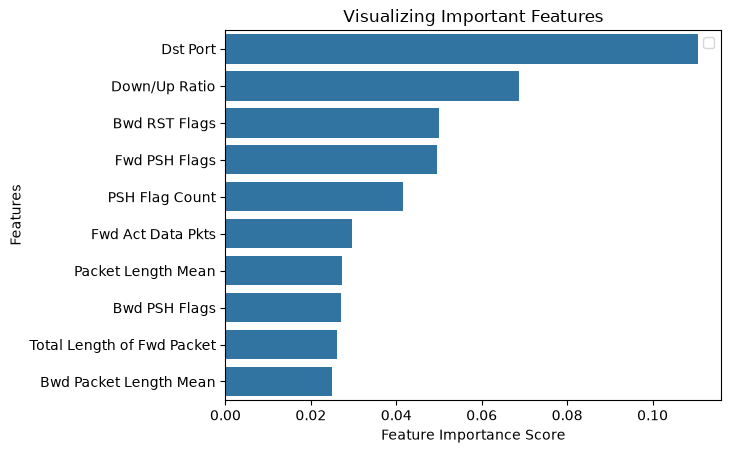

In [55]:
# find important features -> needs better visualization
top_feats = pd.Series(data=rf.feature_importances_, index=X_train.columns)
top_feats.sort_values(ascending=False, inplace=True)
print(top_feats.head(10))

# generate plot
sns.barplot(x=top_feats.head(10).values, y=top_feats.head(10).index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.legend()
plt.show()

In [56]:
# evaluate performance

from sklearn.metrics import confusion_matrix, classification_report

pred_label = rf.predict(X_test)
labels=list(range(len(le.classes_)))

cm=confusion_matrix(y_test, pred_label, labels=labels)
display(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

print(classification_report(y_test, pred_label, labels=labels,target_names=le.classes_, zero_division=0))

        



,BENIGN,FTP-Patator,FTP-Patator - Attempted,SSH-Patator,SSH-Patator - Attempted
BENIGN,63019,0,0,0,0
FTP-Patator,5,806,0,0,0
FTP-Patator - Attempted,2,0,0,0,0
SSH-Patator,35,0,0,542,0
SSH-Patator - Attempted,7,0,0,0,0


                         precision    recall  f1-score   support

                 BENIGN       1.00      1.00      1.00     63019
            FTP-Patator       1.00      0.99      1.00       811
FTP-Patator - Attempted       0.00      0.00      0.00         2
            SSH-Patator       1.00      0.94      0.97       577
SSH-Patator - Attempted       0.00      0.00      0.00         7

               accuracy                           1.00     64416
              macro avg       0.60      0.59      0.59     64416
           weighted avg       1.00      1.00      1.00     64416



[Notes]:

1. There was not much reasoning in the specific values picked for training the model, just wanted to experiment, see if anything would run w/o errors.

2. The accuracy is so high that for sure the model must be overfitting -> maybe we should try on the full dataset -> idk

3. I think training the model and verifying its performance we'll take care of easily -> idk how to compile it to work "outside", i.e. how to integrate it into an app and parse a real PCAP, so it can analyze it

4. switched eval from mae/mse to confusion matrix (mae/mse are for numbers, our labels are categories, 0-4 are just names from LabelEncoder). accuracy also hid that first run caught 0 attacks, it said benign for everything. confusion matrix: rows = real label, columns = predicted, own column = caught, BENIGN column = missed

5. first switched to 200k rows, 0 ssh were caught, upping the rows to whole csv fixed this issue

6. also i think that attempted category leaks the answer, every attempted row has 0/2/3 and everything else is -1, so the model can just read it off

